In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clean data load karo
df = pd.read_csv("Online Retail Cleaned.csv", parse_dates=['InvoiceDate'])
daily_sales = pd.read_csv("daily_sales.csv", parse_dates=['InvoiceDate'])
product_df = pd.read_csv("product_features.csv")
customer_df = pd.read_csv("customer_features.csv")

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

#  Sales Trend (Time Series)

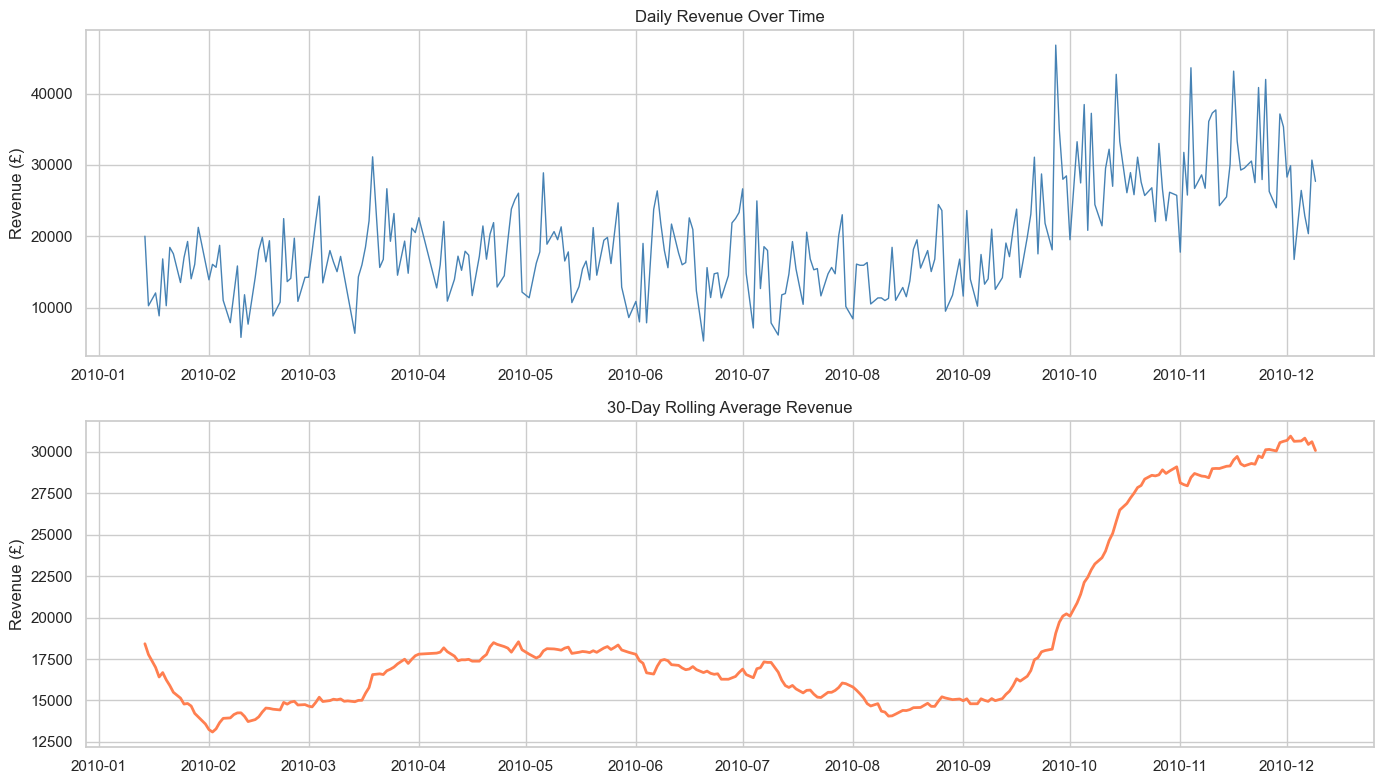

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily revenue
axes[0].plot(daily_sales['InvoiceDate'], daily_sales['Revenue'],
             color='steelblue', linewidth=1)
axes[0].set_title("Daily Revenue Over Time")
axes[0].set_ylabel("Revenue (£)")

# 30-day rolling average
axes[1].plot(daily_sales['InvoiceDate'], daily_sales['RollingMean_30'],
             color='coral', linewidth=2)
axes[1].set_title("30-Day Rolling Average Revenue")
axes[1].set_ylabel("Revenue (£)")

plt.tight_layout()
plt.savefig("plots/sales_trend.png")
plt.show()

#  Monthly & Hourly Patterns

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Date columns dobara banao
df['Month']      = df['InvoiceDate'].dt.month
df['Hour']       = df['InvoiceDate'].dt.hour
df['Day']        = df['InvoiceDate'].dt.day
df['Weekday']    = df['InvoiceDate'].dt.day_name()
df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek
df['Quarter']    = df['InvoiceDate'].dt.quarter


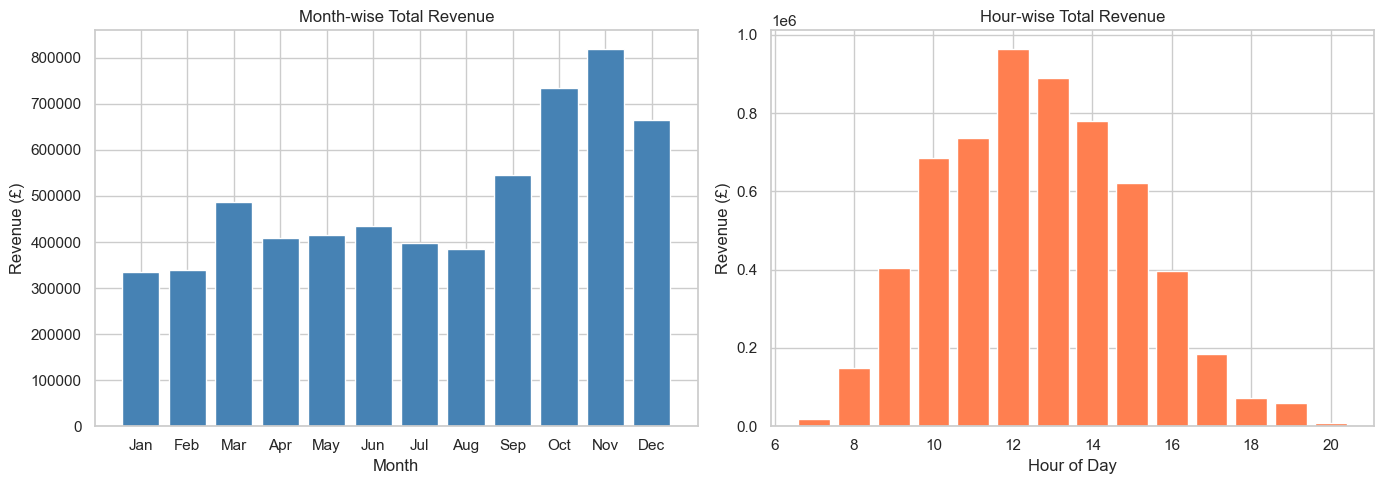

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly sales
monthly = df.groupby('Month')['Total Price'].sum()
axes[0].bar(monthly.index, monthly.values, color='steelblue')
axes[0].set_title("Month-wise Total Revenue")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (£)")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

# Hourly sales
hourly = df.groupby('Hour')['Total Price'].sum()
axes[1].bar(hourly.index, hourly.values, color='coral')
axes[1].set_title("Hour-wise Total Revenue")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Revenue (£)")

plt.tight_layout()
plt.savefig("plots/monthly_hourly.png")
plt.show()

 # top product and countries

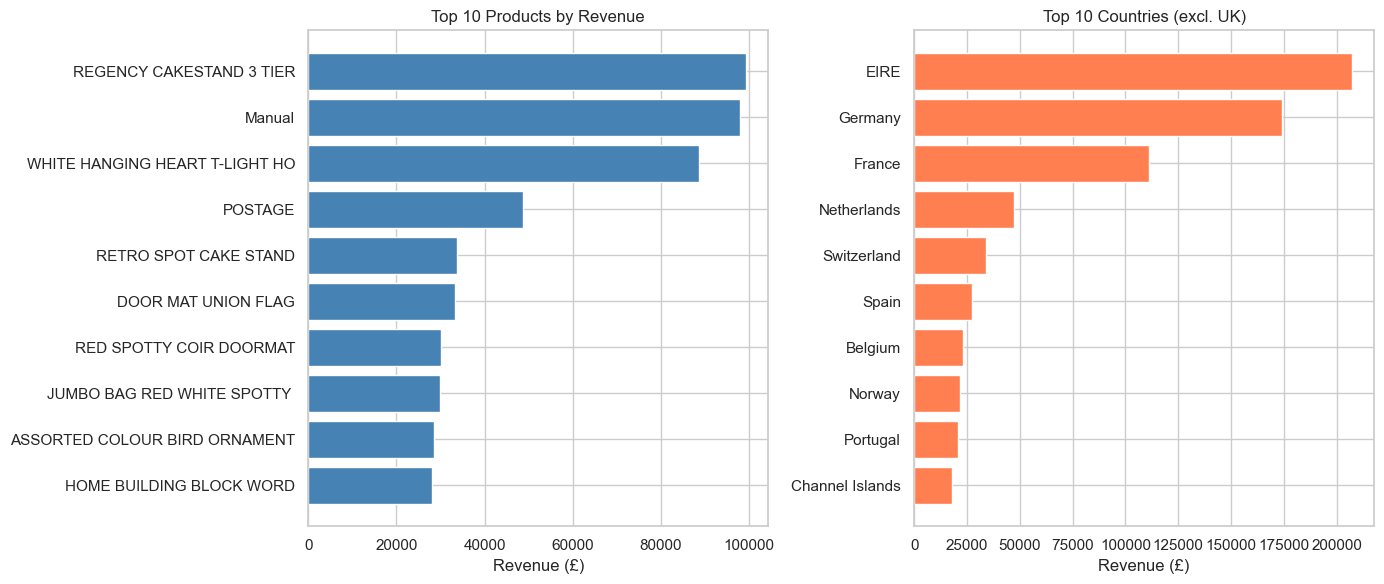

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 products by revenue
top_products = product_df.nlargest(10, 'TotalRevenue')
axes[0].barh(top_products['ProductName'].str[:30],
             top_products['TotalRevenue'],
             color='steelblue')
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue (£)")
axes[0].invert_yaxis()

# Top 10 countries by revenue (UK exclude karo — dominant hai)
country_rev = df[df['Country'] != 'United Kingdom'] \
              .groupby('Country')['Total Price'].sum() \
              .nlargest(10)
axes[1].barh(country_rev.index, country_rev.values, color='coral')
axes[1].set_title("Top 10 Countries (excl. UK)")
axes[1].set_xlabel("Revenue (£)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("plots/top_products_countries.png")
plt.show()

#  Customer Distribution (RFM Preview)

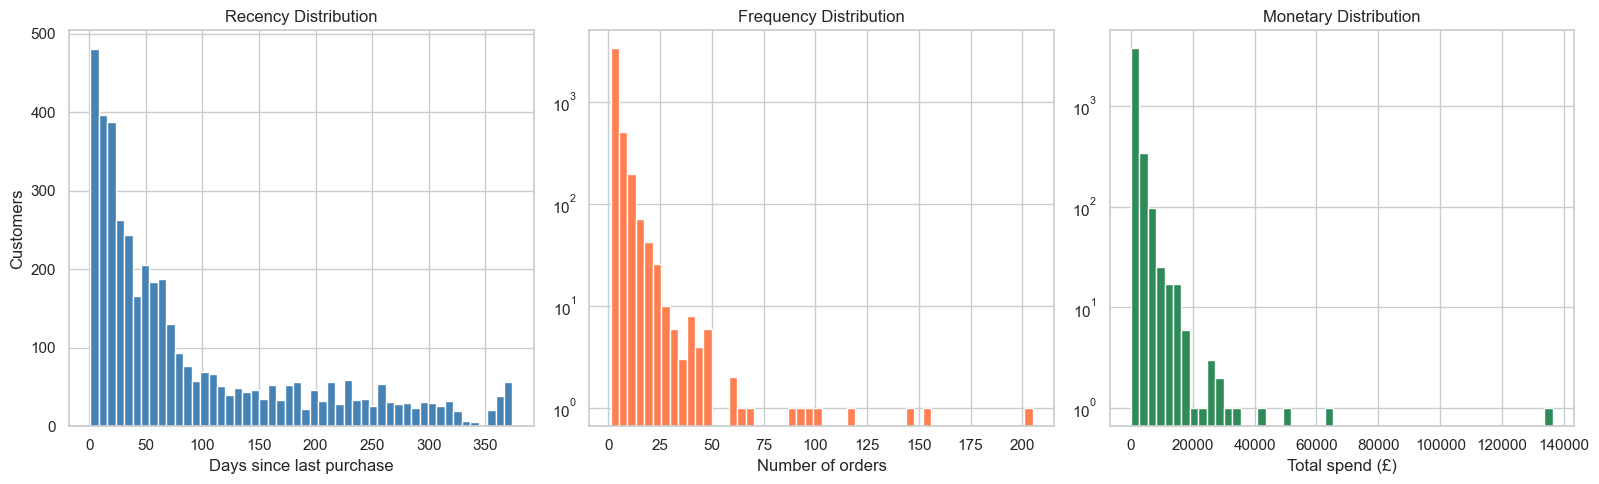

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recency distribution
axes[0].hist(customer_df['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")
axes[0].set_ylabel("Customers")

# Frequency distribution (log scale)
axes[1].hist(customer_df['Frequency'], bins=50, color='coral', edgecolor='white')
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of orders")
axes[1].set_yscale('log')

# Monetary distribution (log scale)
axes[2].hist(customer_df['Monetary'], bins=50, color='seagreen', edgecolor='white')
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total spend (£)")
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig("plots/rfm_distributions.png")
plt.show()

# Correlation Heatmap

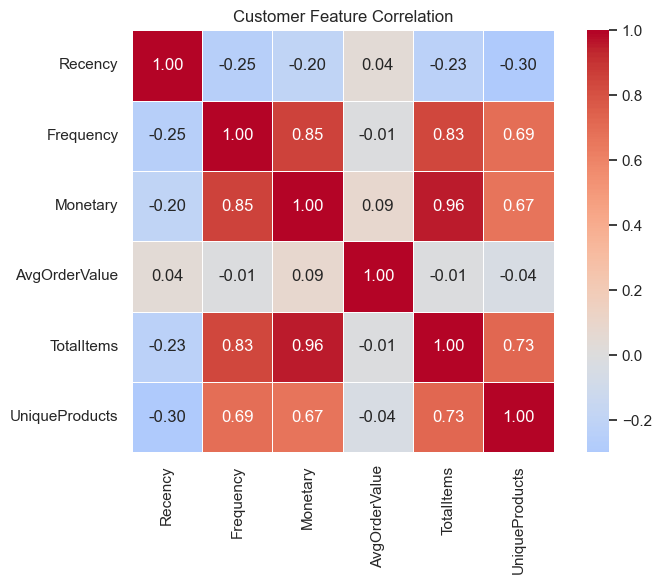

In [14]:
# Customer features ka correlation dekho
cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
        'TotalItems', 'UniqueProducts']

corr = customer_df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title("Customer Feature Correlation")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png")
plt.show()

# Weekday Sales Heatmap

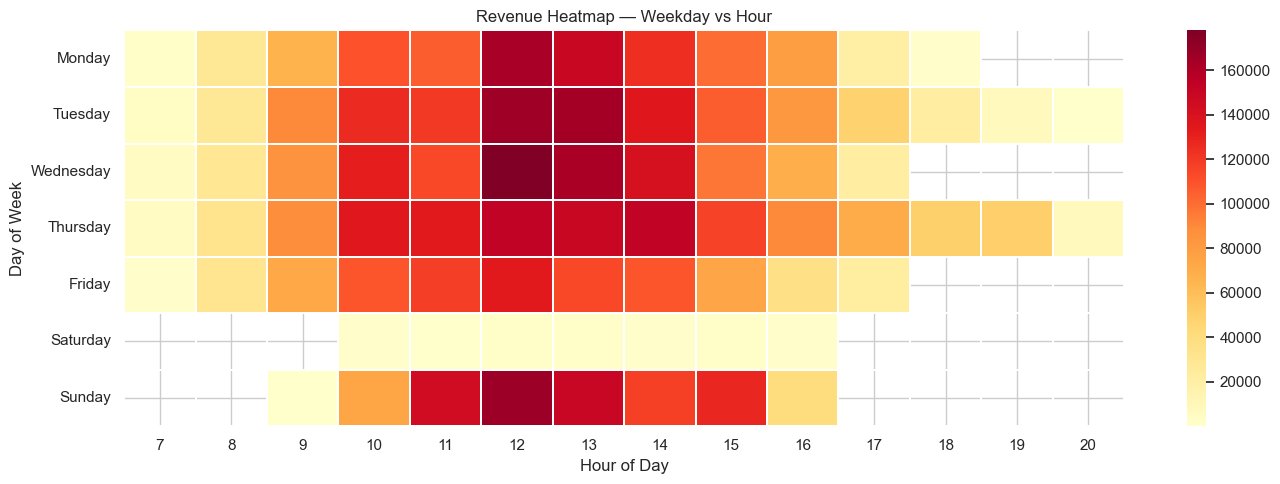

In [15]:
# Weekday x Hour pivot
pivot = df.groupby(['Weekday', 'Hour'])['Total Price'].sum().unstack()

# Correct order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot,
            cmap='YlOrRd',
            linewidths=0.3,
            fmt='.0f')
plt.title("Revenue Heatmap — Weekday vs Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig("plots/weekday_hour_heatmap.png")
plt.show()

In [16]:
import os
os.makedirs("plots", exist_ok=True)
print("Saare EDA plots 'plots/' folder mein save ho gaye!")

Saare EDA plots 'plots/' folder mein save ho gaye!
